
# 🧠 Fundamental Machine Learning using Python for Public Health
## Day 1 — Python Foundations, Feature Engineering & Your First ML Models

**A 2-Day Hands-on Workshop**
Faculty of Public Health, Khon Kaen University

**Instructor:** Teerapong Panboonyuen (Kao) — [kaopanboonyuen.github.io](https://kaopanboonyuen.github.io/)  
**Program:** MPH (Master of Public Health), Department of Biostatistics  
**Dataset:** `kku-stroke-dataset.csv` — [GitHub Repository](https://github.com/kaopanboonyuen/KKU_Biostat_ML_2026s2)    
**Paper reproduced in class:** Melnykova, N., et al. (2025). *Machine learning for stroke prediction using imbalanced data.* Scientific Reports, 15(1), 33773.  

---

###  Acknowledgements:
This workshop is built upon the foundation of the global open-source scientific community. We sincerely acknowledge the developers, researchers, and contributors behind PyTorch, scikit-learn, NumPy, Pandas, Matplotlib, Seaborn, Jupyter Notebook, and Kaggle for advancing reproducible research, machine learning education, and open scientific collaboration.

---

### 🎯 Learning Objectives for Today

By the end of Day 1, you will be able to:

1. Confidently use core **Python** building blocks (variables, control flow, loops, containers, functions, classes) for data science tasks.
2. Load, clean, and explore a real **clinical dataset** with **pandas**.
3. Engineer new features from raw health data the way a data scientist / epidemiologist would — turning raw numbers into clinically meaningful signals.
4. Build a complete **supervised learning pipeline** with **scikit-learn**: preprocessing → stratified split → training → evaluation.
5. Train and compare a **Decision Tree** and a **Random Forest** to predict stroke risk.
6. Read and interpret **feature importance**, **ROC curves**, and a **confusion matrix** like a researcher preparing a paper.

> 💡 **How to use this notebook:** Run every cell in order (Runtime → Run all, or step by step). Cells marked **📝 EXERCISE** are for you to complete.

Let's begin! 🚀



## 0. Setup

We only need the standard scientific Python stack today: `numpy`, `pandas`, `matplotlib`, `seaborn`, and `scikit-learn`. All of these come pre-installed on Google Colab.


In [1]:

# If you are running this OUTSIDE Google Colab and are missing a package, uncomment the line below:
# !pip install -q numpy pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make our plots look clean and consistent throughout the workshop
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42  # fixed seed so every result is reproducible — write this in your papers too!

print("✅ Environment ready. Let's learn some Machine Learning for Public Health!")


✅ Environment ready. Let's learn some Machine Learning for Public Health!



---
# Part A — Python Refresher for Data Science 🐍

We will *speed-run* the Python concepts you already use daily but will need heavily during this workshop. The goal is not to re-teach Python from zero, but to **refresh the exact building blocks used in real data-science code**.



## A.1 Variables and Data Types

Python is dynamically typed — a variable's type is decided by the value you assign to it. In data science, you'll constantly work with these four basic types:

| Type | Example | Used for... |
|---|---|---|
| `int` | `age = 67` | counts, categorical codes |
| `float` | `bmi = 36.6` | measurements (glucose, BMI) |
| `str` | `gender = "Male"` | categorical / text data |
| `bool` | `has_stroke = True` | binary flags, filters |


In [2]:

# --- Basic variable types ---
patient_id = 9046          # int
age = 67                   # int
bmi = 36.6                 # float
gender = "Male"            # str
has_hypertension = False   # bool

print(type(patient_id), type(age), type(bmi), type(gender), type(has_hypertension))

# f-strings: the modern, readable way to build strings (you'll use this A LOT)
print(f"Patient {patient_id} is a {age}-year-old {gender} with BMI {bmi:.1f}")


<class 'int'> <class 'int'> <class 'float'> <class 'str'> <class 'bool'>
Patient 9046 is a 67-year-old Male with BMI 36.6



## A.2 Operators

The operators you will use constantly when engineering features and filtering clinical data:

- **Arithmetic:** `+  -  *  /  //  %  **`
- **Comparison:** `==  !=  >  <  >=  <=`
- **Logical:** `and  or  not`


In [3]:

glucose = 228.69

# Arithmetic
print("Glucose / 10  :", glucose / 10)
print("Glucose // 10 :", glucose // 10)   # floor division
print("Glucose % 10  :", glucose % 10)    # remainder — handy for bucketing!
print("Glucose ** 2  :", glucose ** 2)    # power

# Comparison + logical — this is EXACTLY the logic behind clinical thresholds
is_high_glucose = glucose > 200
is_senior = age >= 65
print("High glucose AND senior patient?", is_high_glucose and is_senior)


Glucose / 10  : 22.869
Glucose // 10 : 22.0
Glucose % 10  : 8.689999999999998
Glucose ** 2  : 52299.1161
High glucose AND senior patient? True



## A.3 Conditionals (`if` / `elif` / `else`)

This is how we encode **clinical decision rules** directly in Python — for example, WHO's BMI categories.


In [4]:

def bmi_category(bmi_value):
    """Classify BMI using WHO adult categories."""
    if bmi_value < 18.5:
        return "Underweight"
    elif bmi_value < 25:
        return "Normal"
    elif bmi_value < 30:
        return "Overweight"
    else:
        return "Obese"

for sample_bmi in [17.2, 22.5, 27.9, 36.6]:
    print(f"BMI {sample_bmi} -> {bmi_category(sample_bmi)}")


BMI 17.2 -> Underweight
BMI 22.5 -> Normal
BMI 27.9 -> Overweight
BMI 36.6 -> Obese



## A.4 Loops (`for` / `while`)

Loops let us process many records at once — the same idea as scanning every row of a dataset.


In [5]:

patient_ages = [67, 61, 80, 49, 79, 12, 5]

# for-loop: the workhorse of data processing
seniors = []
for a in patient_ages:
    if a >= 65:
        seniors.append(a)
print("Senior patients (for-loop):", seniors)

# The same result with a "list comprehension" — Pythonic and used everywhere in pandas/ML code
seniors_comp = [a for a in patient_ages if a >= 65]
print("Senior patients (comprehension):", seniors_comp)

# while-loop: repeat until a condition changes
countdown = 3
while countdown > 0:
    print("Starting workshop in:", countdown)
    countdown -= 1
print("Let's go! 🚀")


Senior patients (for-loop): [67, 80, 79]
Senior patients (comprehension): [67, 80, 79]
Starting workshop in: 3
Starting workshop in: 2
Starting workshop in: 1
Let's go! 🚀



## A.5 Containers: `list`, `tuple`, `dict`, `set`

| Container | Ordered? | Mutable? | Typical ML use |
|---|---|---|---|
| `list` | ✅ | ✅ | rows, feature lists, results |
| `tuple` | ✅ | ❌ | fixed records, function returns (e.g. `X_train, X_test`) |
| `dict` | ✅ (insertion order) | ✅ | mapping categories → codes, storing model results |
| `set` | ❌ | ✅ | unique categories, fast membership tests |


In [6]:

# list — ordered, changeable collection
smoking_statuses = ["formerly smoked", "never smoked", "smokes", "Unknown"]
smoking_statuses.append("never smoked")  # duplicates allowed
print("list:", smoking_statuses)

# tuple — fixed-size, cannot be changed (used everywhere in sklearn, e.g. X_train, X_test = ...)
train_test_shapes = (3577, 1533)
print("tuple:", train_test_shapes, "-> train size:", train_test_shapes[0])

# dict — key/value mapping, perfect for encoding categories
work_type_map = {
    "Private": 0,
    "Self-employed": 1,
    "Govt_job": 2,
    "children": 3,
    "Never_worked": 4,
}
print("dict lookup:", work_type_map["Self-employed"])

# set — unique values only, great for "what categories exist in this column?"
unique_statuses = set(smoking_statuses)
print("set (unique values):", unique_statuses)


list: ['formerly smoked', 'never smoked', 'smokes', 'Unknown', 'never smoked']
tuple: (3577, 1533) -> train size: 3577
dict lookup: 1
set (unique values): {'smokes', 'never smoked', 'formerly smoked', 'Unknown'}



## A.6 Functions

Functions package logic into a reusable, testable unit — exactly what we did with `bmi_category()` above. Key idea: **inputs (parameters) → logic → output (return value)**.


In [7]:

def glucose_category(glucose_value):
    """Classify average glucose level (mg/dL) into clinical categories.

    < 140       : Normal
    140 - 199   : Prediabetes
    >= 200      : Diabetes range
    """
    if glucose_value < 140:
        return "Normal"
    elif glucose_value < 200:
        return "Prediabetes"
    else:
        return "Diabetes range"

# default arguments + docstrings are considered good practice
def risk_flag(age, hypertension, heart_disease, age_threshold=65):
    """Return a simple composite risk flag (toy example, NOT a real clinical score)."""
    score = int(age >= age_threshold) + hypertension + heart_disease
    return score

print(glucose_category(228.69))
print("Composite risk score:", risk_flag(age=67, hypertension=0, heart_disease=1))


Diabetes range
Composite risk score: 2



## A.7 Classes (just enough OOP for data science)

You don't need to be an OOP expert, but you *will* see classes everywhere (`DecisionTreeClassifier()`, `StandardScaler()`, ...). Here's the minimum you need to understand what's happening under the hood.


In [8]:

class Patient:
    """A tiny class representing one patient record."""

    def __init__(self, patient_id, age, bmi, smoking_status):
        # __init__ runs when we CREATE the object — it stores the attributes
        self.patient_id = patient_id
        self.age = age
        self.bmi = bmi
        self.smoking_status = smoking_status

    def is_high_risk(self):
        # a METHOD — a function that belongs to the object and can use its own attributes
        return self.age >= 65 and self.bmi >= 30

p1 = Patient(patient_id=9046, age=67, bmi=36.6, smoking_status="formerly smoked")
print(f"Patient {p1.patient_id}: age={p1.age}, bmi={p1.bmi}")
print("High risk?", p1.is_high_risk())

# This is EXACTLY the pattern used by scikit-learn:
# model = DecisionTreeClassifier(max_depth=5)   <- __init__ sets hyperparameters
# model.fit(X_train, y_train)                   <- a method that changes internal state
# model.predict(X_test)                         <- a method that returns a result


Patient 9046: age=67, bmi=36.6
High risk? True



---
## 📝 EXERCISE SET 1 — Python Warm-up (3 short questions)

Try each question yourself first before looking at the solution below it!

**Q1. (Easy)** Write a function `is_smoker(status)` that returns `True` if `status` is `"smokes"` or `"formerly smoked"`, and `False` otherwise.

**Q2. (Medium)** Given the list `ages = [67, 61, 80, 49, 12, 5, 3]`, use a list comprehension to create a new list `adult_ages` containing only ages `>= 18`.

**Q3. (Harder)** Write a function `age_group(age)` that returns one of `"Child"` (0–17), `"Adult"` (18–64), or `"Senior"` (65+). Then use it inside a loop to print the group for every age in `ages`.


In [9]:

# ✍️ Your turn! Write your code here before checking the solution below.






### ✅ SOLUTION — Exercise Set 1
*(Instructor note: delete this cell and the one below for the version you hand out live, then reveal after students attempt it.)*


In [10]:

# Q1
def is_smoker(status):
    return status in ("smokes", "formerly smoked")

print("Q1:", is_smoker("smokes"), is_smoker("never smoked"))

# Q2
ages = [67, 61, 80, 49, 12, 5, 3]
adult_ages = [a for a in ages if a >= 18]
print("Q2:", adult_ages)

# Q3
def age_group(age):
    if age < 18:
        return "Child"
    elif age < 65:
        return "Adult"
    else:
        return "Senior"

print("Q3:")
for a in ages:
    print(f"  age={a:>3} -> {age_group(a)}")


Q1: True False
Q2: [67, 61, 80, 49]
Q3:
  age= 67 -> Senior
  age= 61 -> Adult
  age= 80 -> Senior
  age= 49 -> Adult
  age= 12 -> Child
  age=  5 -> Child
  age=  3 -> Child



---
# Part B — Loading & Exploring the Stroke Dataset with `pandas` 🩺

Now that our Python fundamentals are warmed up, let's move to **real public-health data**.

We will use the **KKU Stroke Dataset** (`kku-stroke-dataset.csv`), a cleaned teaching version of the well-known stroke-prediction dataset, hosted for this course at:

`https://github.com/kaopanboonyuen/KKU_Biostat_ML_2026s2`

**Prediction task:** Binary classification — will a patient have a stroke (`stroke = 1`) or not (`stroke = 0`)?

| Variable | Type | Description |
|---|---|---|
| `id` | Integer | Unique participant identifier |
| `gender` | Categorical | Male / Female / Other |
| `age` | Numeric | Age in years |
| `hypertension` | Binary | 0 = No, 1 = Yes |
| `heart_disease` | Binary | 0 = No, 1 = Yes |
| `ever_married` | Categorical | Yes / No |
| `work_type` | Categorical | Private, Self-employed, Govt_job, children, Never_worked |
| `Residence_type` | Categorical | Urban / Rural |
| `avg_glucose_level` | Numeric | Average blood glucose (mg/dL) |
| `bmi` | Numeric | Body Mass Index (kg/m²) — contains missing values (`N/A`) |
| `smoking_status` | Categorical | never smoked / formerly smoked / smokes / Unknown |
| `stroke` | Binary (**target**) | 0 = No stroke, 1 = Stroke |


In [11]:
# -----------------------------------------------------------------------------
# Dataset configuration
# -----------------------------------------------------------------------------
DATASET_NAME = "kku-stroke-dataset"

GITHUB_BASE_URL = (
    "https://raw.githubusercontent.com/"
    "kaopanboonyuen/KKU_Biostat_ML_2026s2/main/dataset"
)

DATA_URL = f"{GITHUB_BASE_URL}/{DATASET_NAME}.csv"

# -----------------------------------------------------------------------------
# Load dataset
# -----------------------------------------------------------------------------
# Treat the string "N/A" as missing values (NaN)
df = pd.read_csv(DATA_URL, na_values=["N/A"])

print(f"Dataset: {DATASET_NAME}")
print(f"Shape (rows, columns): {df.shape}")

df.head()

Dataset: kku-stroke-dataset
Shape (rows, columns): (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



## B.1 First Look at the Data

Three commands you should run on *every* new dataset, always, before doing anything else:

- `df.info()` — column names, data types, non-null counts
- `df.describe()` — summary statistics for numeric columns
- `df.isna().sum()` — missing values per column


In [12]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [13]:

df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,5110.0,NaN,NaN,NaN,36517.829354,21161.721625,67.0,17741.25,36932.0,54682.0,72940.0
gender,5110,3,Female,2994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5110.0,NaN,NaN,NaN,43.226614,22.612647,0.08,25.0,45.0,61.0,82.0
hypertension,5110.0,NaN,NaN,NaN,0.097456,0.296607,0.0,0.0,0.0,0.0,1.0
heart_disease,5110.0,NaN,NaN,NaN,0.054012,0.226063,0.0,0.0,0.0,0.0,1.0
ever_married,5110,2,Yes,3353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_type,5110,5,Private,2925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Residence_type,5110,2,Urban,2596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_glucose_level,5110.0,NaN,NaN,NaN,106.147677,45.28356,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,NaN,NaN,NaN,28.893237,7.854067,10.3,23.5,28.1,33.1,97.6


In [14]:

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct(%)": missing_pct})


,missing_count,missing_pct(%)
bmi,201,3.93
id,0,0.00
gender,0,0.00
age,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
ever_married,0,0.00
work_type,0,0.00
Residence_type,0,0.00
avg_glucose_level,0,0.00



👉 **Observation:** `bmi` is the only column with missing values. This matches exactly what we expect from the data dictionary — we will handle it properly during feature engineering (never just silently drop rows in health data — you may be throwing away sick patients!).

## B.2 Target Distribution — Is This Dataset Imbalanced?

This is one of the **most important checks** in any clinical ML project. Rare-disease datasets (like stroke) are almost always **imbalanced**: far more "no stroke" cases than "stroke" cases.


stroke
0    4861
1     249
Name: count, dtype: int64

stroke
0    95.13 %
1     4.87 %
Name: proportion, dtype: object


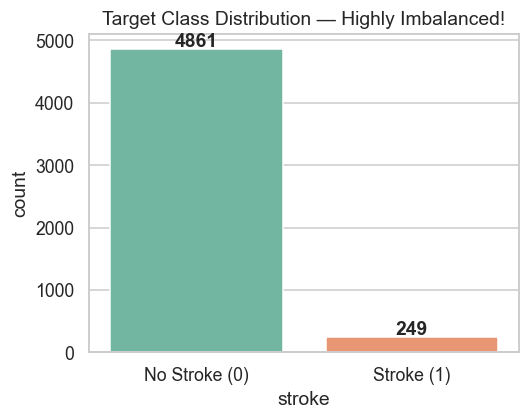

In [15]:

counts = df["stroke"].value_counts()
pct = df["stroke"].value_counts(normalize=True) * 100

print(counts)
print()
print(pct.round(2).astype(str) + " %")

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="stroke", data=df, hue="stroke", palette="Set2", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Stroke (0)", "Stroke (1)"])
ax.set_title("Target Class Distribution — Highly Imbalanced!")
for i, v in enumerate(counts.sort_index()):
    ax.text(i, v + 30, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()



> ⚠️ **Why this matters:** if ~95% of patients did NOT have a stroke, a lazy model that *always* predicts "no stroke" would already score ~95% accuracy — while being clinically useless! This is exactly why we will also look at **precision, recall, F1, and ROC-AUC** later, not just accuracy. We will revisit imbalance handling on Day 2.

## B.3 Deep Exploratory Data Analysis (EDA)

Let's look at the data from many angles: numeric distributions, categorical breakdowns, and relationships with the target.


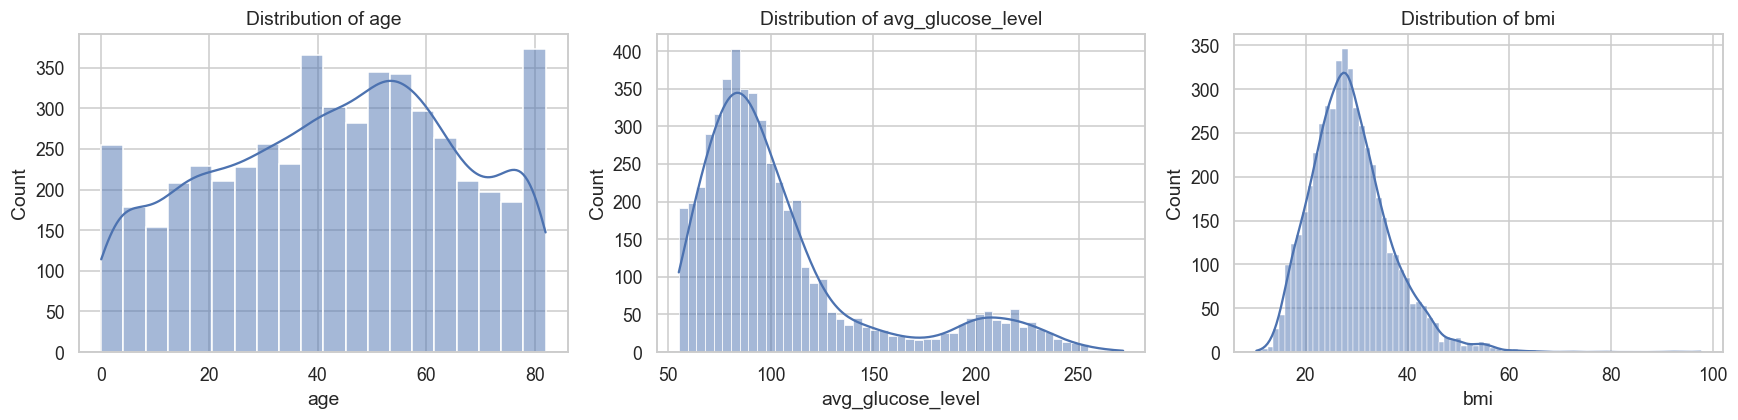

In [16]:

numeric_cols = ["age", "avg_glucose_level", "bmi"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


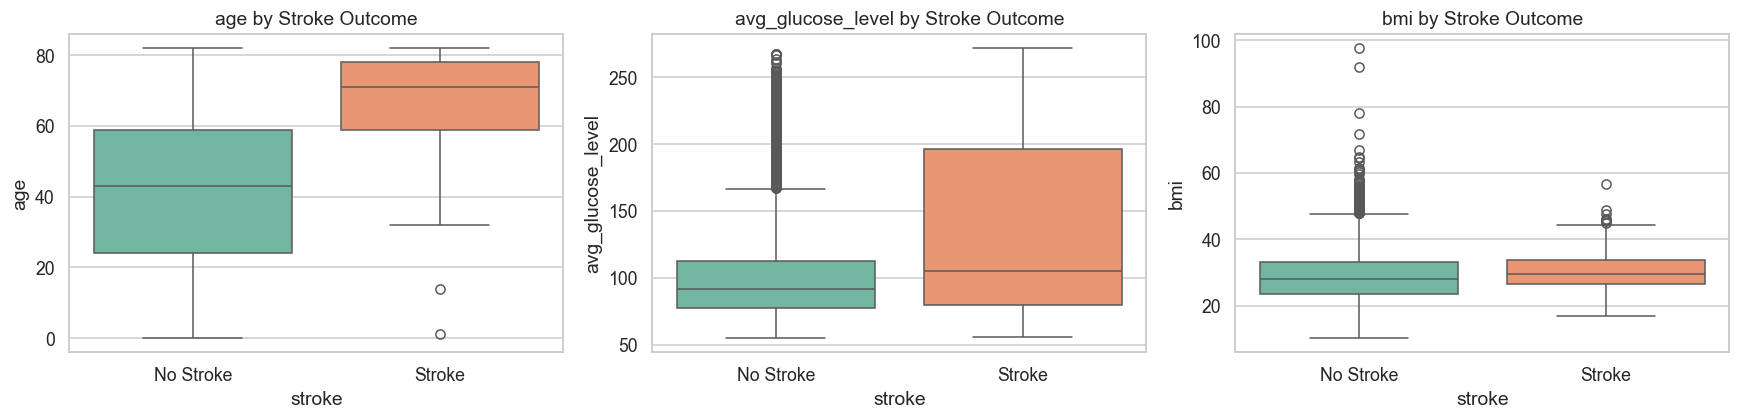

In [17]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x="stroke", y=col, data=df, hue="stroke", palette="Set2", legend=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No Stroke", "Stroke"])
    ax.set_title(f"{col} by Stroke Outcome")
plt.tight_layout()
plt.show()


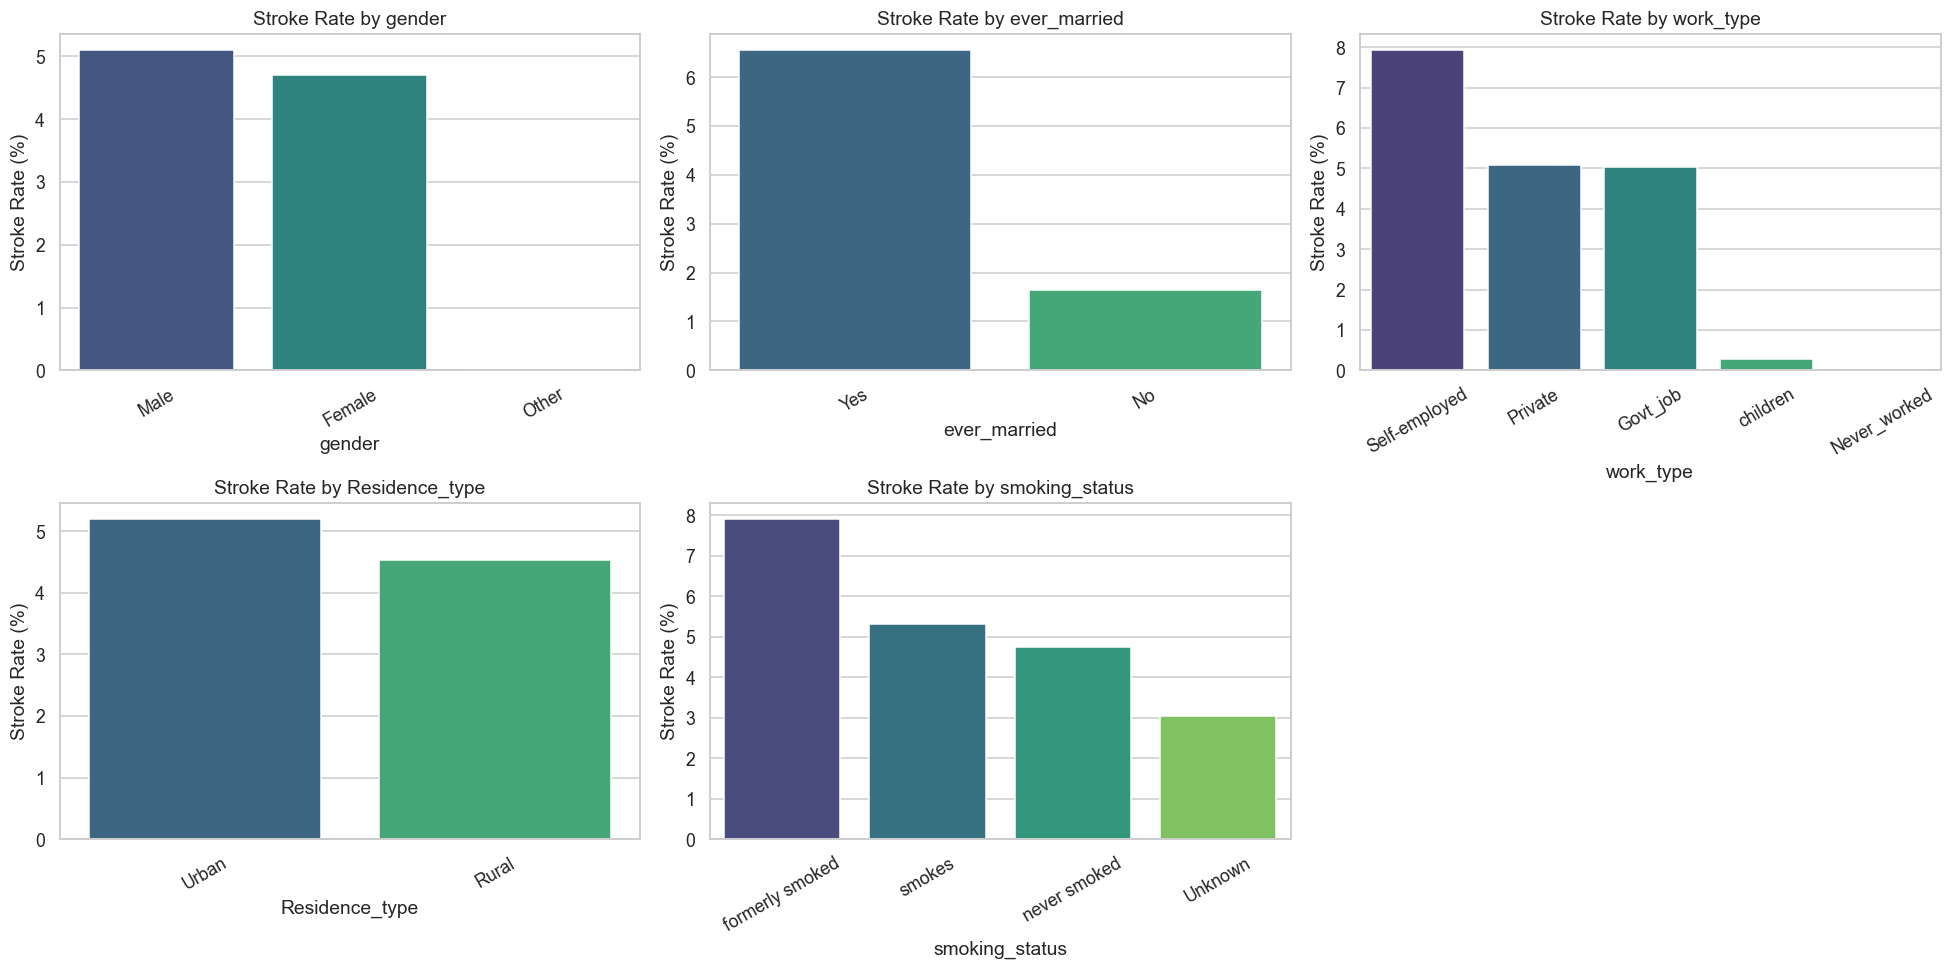

In [18]:

categorical_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for ax, col in zip(axes, categorical_cols):
    stroke_rate = df.groupby(col)["stroke"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=stroke_rate.index, y=stroke_rate.values, hue=stroke_rate.index,
                palette="viridis", legend=False, ax=ax)
    ax.set_ylabel("Stroke Rate (%)")
    ax.set_title(f"Stroke Rate by {col}")
    ax.tick_params(axis="x", rotation=30)
axes[-1].axis("off")
plt.tight_layout()
plt.show()


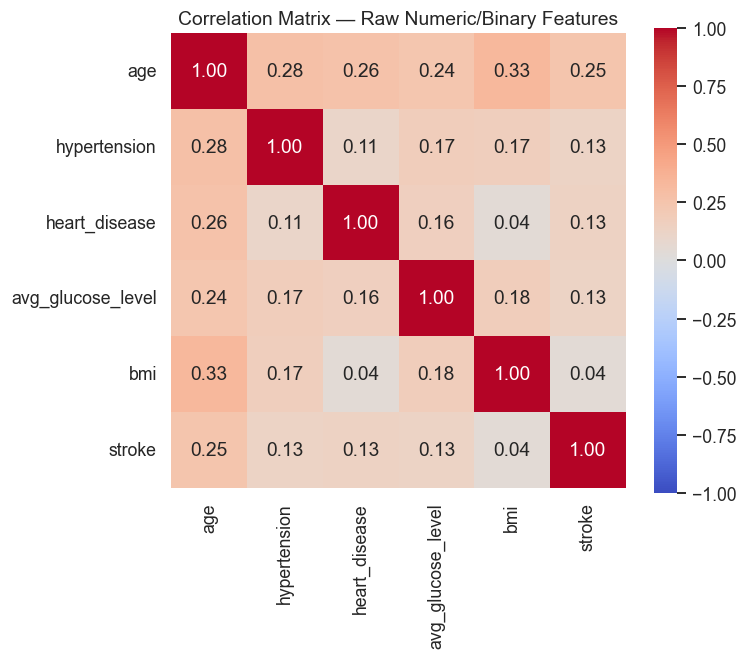

In [19]:

# Correlation heatmap for the numeric + binary columns already available
corr_cols = ["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi", "stroke"]
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix — Raw Numeric/Binary Features")
plt.tight_layout()
plt.show()



👉 **Reading the plots:** notice how `age` clearly separates stroke vs. no-stroke patients, and stroke rate rises sharply with `hypertension`, `heart_disease`, and being `formerly smoked` / `smokes`. `age` also has the strongest raw correlation with `stroke`. This kind of visual evidence is exactly what you'd put in the "Results" section of a public-health paper.

---
# Part C — Feature Engineering: Thinking Like a Data Scientist 🔧

Raw columns are rarely the best inputs to a model. **Feature engineering** means transforming raw data into new variables that better expose the underlying signal — this is where domain knowledge (epidemiology!) and data science meet.

We'll build features in increasing order of sophistication:

1. **Missing-value imputation** for `bmi` (median, and a smarter group-wise median)
2. **Clinical binning**: BMI categories (WHO), glucose categories (ADA), age groups
3. **Encoding categorical variables**: label encoding vs. one-hot encoding
4. **Interaction / composite features**: combining risk factors into a single score
5. **Skew correction**: log-transforming a right-skewed variable


In [20]:

# Work on a COPY so the original df is always available for reference
data = df.copy()

# ------------------------------------------------------------------
# C.1 — Missing value imputation for BMI
# ------------------------------------------------------------------
# Naive approach: fill with the overall median
median_bmi_overall = data["bmi"].median()

# Smarter, "expert" approach: fill with the median BMI of patients in the
# SAME age group and gender — people of similar age/sex tend to have similar BMI,
# so this preserves more real signal than a single global number.
data["age_bin_for_impute"] = pd.cut(data["age"], bins=[0, 18, 40, 60, 80, 120])

data["bmi"] = data.groupby(["age_bin_for_impute", "gender"])["bmi"].transform(
    lambda s: s.fillna(s.median())
)
# Safety net: if a (age_bin, gender) group had NO data at all, fall back to the global median
data["bmi"] = data["bmi"].fillna(median_bmi_overall)
data.drop(columns=["age_bin_for_impute"], inplace=True)

print("Remaining missing BMI values:", data["bmi"].isna().sum())


Remaining missing BMI values: 0


In [21]:

# ------------------------------------------------------------------
# C.2 — Clinical binning: turn continuous numbers into meaningful categories
# ------------------------------------------------------------------

def bmi_category(bmi_value):
    """WHO adult BMI categories."""
    if bmi_value < 18.5:
        return "Underweight"
    elif bmi_value < 25:
        return "Normal"
    elif bmi_value < 30:
        return "Overweight"
    else:
        return "Obese"

def glucose_category(glucose_value):
    """ADA-style average glucose categories (mg/dL)."""
    if glucose_value < 140:
        return "Normal"
    elif glucose_value < 200:
        return "Prediabetes"
    else:
        return "Diabetes_range"

data["bmi_category"] = data["bmi"].apply(bmi_category)
data["glucose_category"] = data["avg_glucose_level"].apply(glucose_category)

# Age groups often used in epidemiology
data["age_group"] = pd.cut(
    data["age"],
    bins=[0, 18, 40, 60, 80, 120],
    labels=["0-18", "19-40", "41-60", "61-80", "81+"],
)

data[["bmi", "bmi_category", "avg_glucose_level", "glucose_category", "age", "age_group"]].head()


,bmi,bmi_category,avg_glucose_level,glucose_category,age,age_group
0,36.6,Obese,228.69,Diabetes_range,67.0,61-80
1,29.2,Overweight,202.21,Diabetes_range,61.0,61-80
2,32.5,Obese,105.92,Normal,80.0,61-80
3,34.4,Obese,171.23,Prediabetes,49.0,41-60
4,24.0,Normal,174.12,Prediabetes,79.0,61-80


In [22]:

# ------------------------------------------------------------------
# C.3 — Encoding categorical variables
# ------------------------------------------------------------------
# Two common strategies:
#  (a) Label encoding: map categories to integers (0, 1, 2, ...) — simple, but implies
#      an ORDER between categories, which is fine for tree-based models like our
#      Decision Tree / Random Forest, but risky for linear models (careful on Day 2!).
#  (b) One-hot encoding: create a 0/1 dummy column per category — no false ordering,
#      the standard choice for linear models & neural networks.

binary_map = {"Yes": 1, "No": 0}
data["ever_married_flag"] = data["ever_married"].map(binary_map)
data = data.drop(columns=["ever_married"])  # replaced by the numeric flag above

# One-hot encoding for the remaining nominal categorical variables
categorical_for_ohe = ["gender", "work_type", "Residence_type", "smoking_status",
                        "bmi_category", "glucose_category", "age_group"]

data_encoded = pd.get_dummies(data, columns=categorical_for_ohe, drop_first=False)

print("Columns BEFORE encoding:", data.shape[1])
print("Columns AFTER one-hot encoding:", data_encoded.shape[1])
data_encoded.head()


Columns BEFORE encoding: 15
Columns AFTER one-hot encoding: 34


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,ever_married_flag,gender_Female,gender_Male,...,bmi_category_Overweight,bmi_category_Underweight,glucose_category_Diabetes_range,glucose_category_Normal,glucose_category_Prediabetes,age_group_0-18,age_group_19-40,age_group_41-60,age_group_61-80,age_group_81+
0,9046,67.0,0,1,228.69,36.6,1,1,False,True,...,False,False,True,False,False,False,False,False,True,False
1,51676,61.0,0,0,202.21,29.2,1,1,True,False,...,True,False,True,False,False,False,False,False,True,False
2,31112,80.0,0,1,105.92,32.5,1,1,False,True,...,False,False,False,True,False,False,False,False,True,False
3,60182,49.0,0,0,171.23,34.4,1,1,True,False,...,False,False,False,False,True,False,False,True,False,False
4,1665,79.0,1,0,174.12,24.0,1,1,True,False,...,False,False,False,False,True,False,False,False,True,False


In [23]:

# ------------------------------------------------------------------
# C.4 — Interaction / composite risk features
# ------------------------------------------------------------------
# Experts rarely rely on raw features alone — combining variables can reveal
# risk patterns invisible to any single column.

# (a) Comorbidity count: how many known risk conditions does this patient have?
data_encoded["comorbidity_count"] = data["hypertension"] + data["heart_disease"]

# (b) Age x Hypertension interaction: hypertension is riskier at older ages
data_encoded["age_x_hypertension"] = data["age"] * data["hypertension"]

# (c) Metabolic risk score: a simple composite of glucose + bmi, both scaled to comparable ranges
data_encoded["metabolic_risk_score"] = (
    (data["avg_glucose_level"] / data["avg_glucose_level"].max()) * 0.5
    + (data["bmi"] / data["bmi"].max()) * 0.5
)

# (d) Senior flag: a simple, highly-interpretable binary marker used constantly in clinical papers
data_encoded["is_senior"] = (data["age"] >= 65).astype(int)

data_encoded[["comorbidity_count", "age_x_hypertension", "metabolic_risk_score", "is_senior"]].describe()


,comorbidity_count,age_x_hypertension,metabolic_risk_score,is_senior
count,5110.000000,5110.000000,5110.000000,5110.000000
mean,0.151468,6.066145,0.343230,0.200978
std,0.391924,18.975562,0.098133,0.400771
min,0.000000,0.000000,0.171080,0.000000
25%,0.000000,0.000000,0.279549,0.000000
50%,0.000000,0.000000,0.318239,0.000000
75%,0.000000,0.000000,0.371532,0.000000
max,2.000000,82.000000,0.755622,1.000000


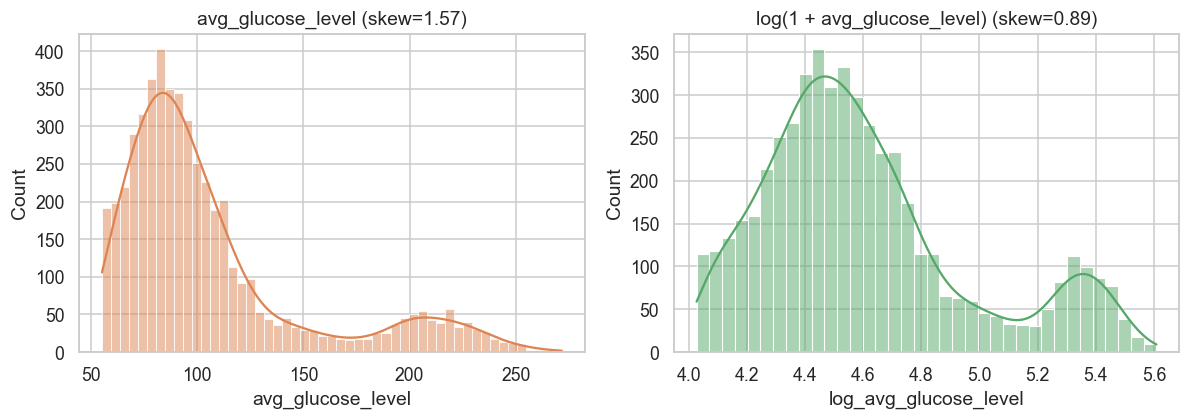

In [24]:

# ------------------------------------------------------------------
# C.5 — Skew correction (log transform)
# ------------------------------------------------------------------
# avg_glucose_level is right-skewed (many "normal" patients, a long tail of very high values).
# A log transform compresses that tail, which can help some models (especially linear ones on Day 2).

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data_encoded["avg_glucose_level"], kde=True, ax=axes[0], color="#DD8452")
axes[0].set_title(f"avg_glucose_level (skew={data_encoded['avg_glucose_level'].skew():.2f})")

data_encoded["log_avg_glucose_level"] = np.log1p(data_encoded["avg_glucose_level"])
sns.histplot(data_encoded["log_avg_glucose_level"], kde=True, ax=axes[1], color="#55A868")
axes[1].set_title(f"log(1 + avg_glucose_level) (skew={data_encoded['log_avg_glucose_level'].skew():.2f})")
plt.tight_layout()
plt.show()



---
## 📝 EXERCISE SET 2 — Feature Engineering (easy → hard)

**Q1. (Easy)** Create a new binary column `high_bmi_flag` that is `1` if `bmi >= 30` (Obese, WHO) and `0` otherwise.

**Q2. (Medium)** Create a column `smoker_flag` that is `1` if `smoking_status` is `"smokes"` or `"formerly smoked"`, and `0` otherwise (hint: reuse the logic from Exercise Set 1!).

**Q3. (Harder)** Create a composite column `lifestyle_risk_score` that adds up: `smoker_flag` + `high_bmi_flag` + `hypertension` + `heart_disease`. Then check whether the **mean stroke rate increases monotonically** as `lifestyle_risk_score` goes from 0 to 4 (use `data.groupby("lifestyle_risk_score")["stroke"].mean()`).


In [25]:

# ✍️ Your turn! Write your code here before checking the solution below.






### ✅ SOLUTION — Exercise Set 2


Stroke rate (%) by lifestyle_risk_score:
lifestyle_risk_score
0     2.67
1     4.92
2     7.52
3    13.37
4    27.78
Name: stroke, dtype: float64


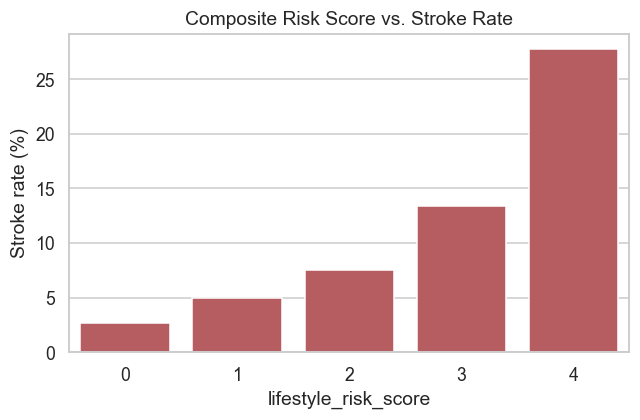

In [26]:

# Q1
data["high_bmi_flag"] = (data["bmi"] >= 30).astype(int)

# Q2
data["smoker_flag"] = data["smoking_status"].isin(["smokes", "formerly smoked"]).astype(int)

# Q3
data["lifestyle_risk_score"] = (
    data["smoker_flag"] + data["high_bmi_flag"] + data["hypertension"] + data["heart_disease"]
)

risk_vs_stroke = data.groupby("lifestyle_risk_score")["stroke"].mean() * 100
print("Stroke rate (%) by lifestyle_risk_score:")
print(risk_vs_stroke.round(2))

plt.figure(figsize=(6, 4))
sns.barplot(x=risk_vs_stroke.index, y=risk_vs_stroke.values, color="#C44E52")
plt.ylabel("Stroke rate (%)")
plt.xlabel("lifestyle_risk_score")
plt.title("Composite Risk Score vs. Stroke Rate")
plt.tight_layout()
plt.show()

# copy the engineered columns from `data` onto `data_encoded` so they flow into Part D
for col in ["high_bmi_flag", "smoker_flag", "lifestyle_risk_score"]:
    data_encoded[col] = data[col]



---
# Part D — Your First Machine Learning Models 🤖

We now have a rich, engineered feature set. Time to build a real **supervised learning pipeline**:

1. Select features / target
2. **Stratified** train/test split (important for imbalanced data!)
3. Train a **Decision Tree** and a **Random Forest**
4. Inspect **feature importance**
5. Evaluate on the untouched test set with a full metric suite


In [27]:

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)

# Drop identifiers / raw columns already represented by engineered features
drop_cols = ["id"]
feature_cols = [c for c in data_encoded.columns if c not in drop_cols + ["stroke"]]

X = data_encoded[feature_cols]
y = data_encoded["stroke"]

print("Final feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True).round(3))


Final feature matrix shape: (5110, 40)
Target distribution:
 stroke
0    0.951
1    0.049
Name: proportion, dtype: float64



## D.1 Stratified Train/Test Split

`stratify=y` guarantees that the **same proportion of stroke vs. no-stroke** patients appears in both the training and test sets — critical for imbalanced clinical data, otherwise you might get unlucky and have almost no positive cases in your test set!


In [28]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,   # <-- keeps class balance identical in train & test
)

print("Train shape:", X_train.shape, " | Test shape:", X_test.shape)
print("Train stroke rate: %.2f%% | Test stroke rate: %.2f%%" % (
    y_train.mean() * 100, y_test.mean() * 100
))


Train shape: (3832, 40)  | Test shape: (1278, 40)
Train stroke rate: 4.88% | Test stroke rate: 4.85%



## D.2 Training a Decision Tree

A **Decision Tree** learns a series of yes/no questions (e.g. "is age > 62?") that split the data into purer and purer groups with respect to the target.

**Key hyperparameters (and how to think about tuning them):**

| Parameter | What it controls | Tuning intuition |
|---|---|---|
| `max_depth` | Maximum number of question-levels | Too small → underfits (misses patterns). Too large → overfits (memorizes noise). Start around 4-8 and tune. |
| `min_samples_split` | Minimum samples needed to split a node further | Higher values = simpler, more conservative tree |
| `min_samples_leaf` | Minimum samples allowed in a leaf | Prevents tiny, unreliable leaves from single outlier patients |
| `class_weight="balanced"` | Automatically re-weights rare class | Very useful for imbalanced clinical outcomes like stroke |
| `criterion` | Splitting quality measure (`gini` or `entropy`) | Usually gini is fine and faster; entropy is sometimes marginally more informative |


In [29]:

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    class_weight="balanced",   # important! stroke is rare
    random_state=RANDOM_STATE,
)
dt_model.fit(X_train, y_train)
print("✅ Decision Tree trained.")


✅ Decision Tree trained.


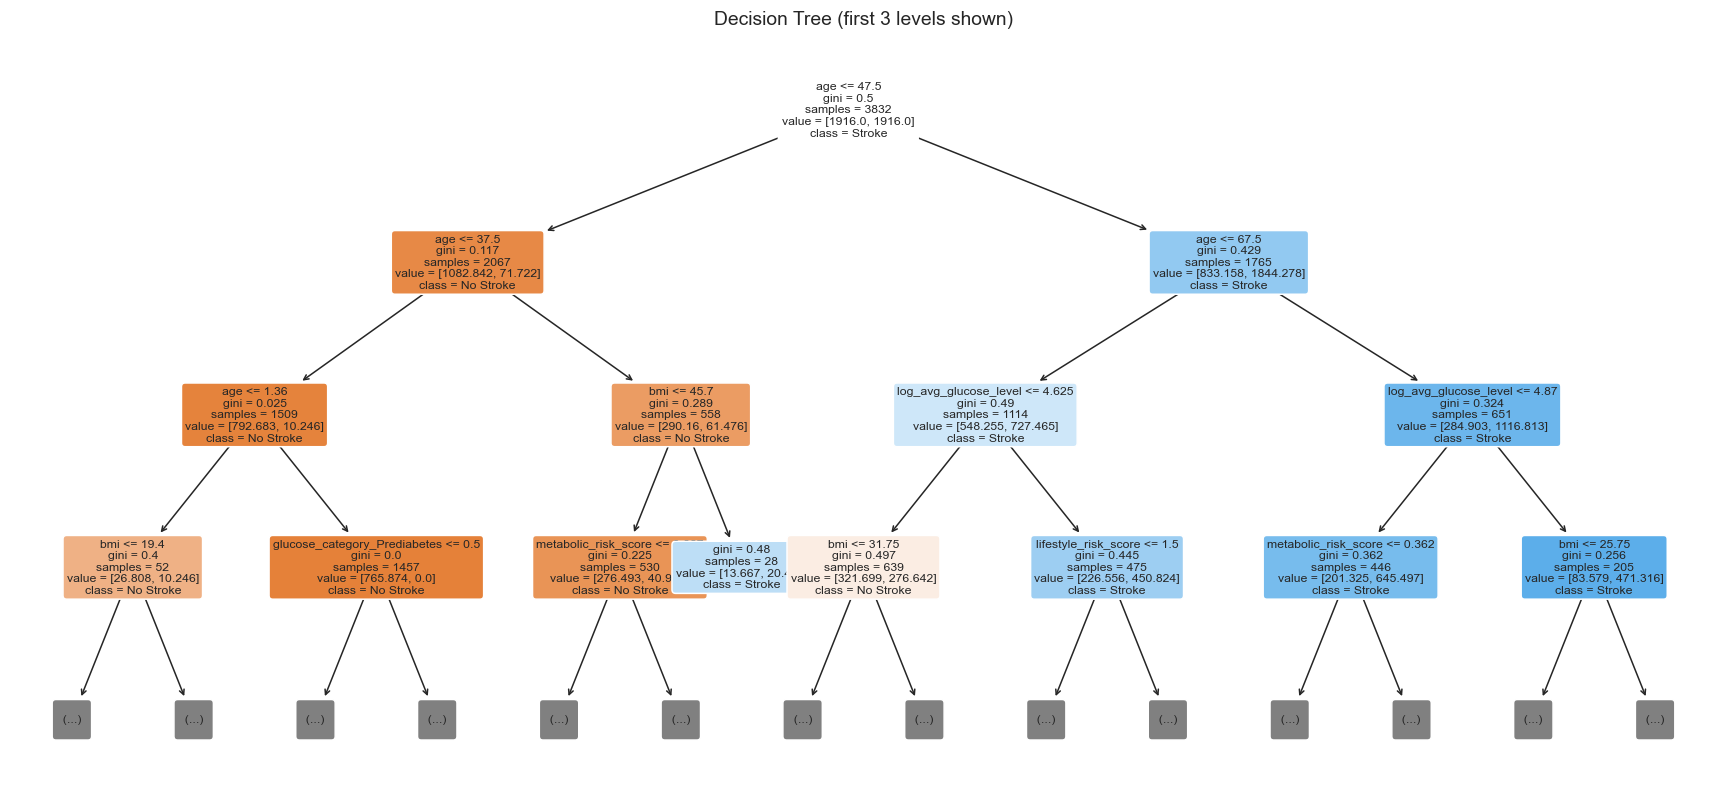

In [30]:

plt.figure(figsize=(20, 9))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Stroke", "Stroke"],
    filled=True, rounded=True, fontsize=8, max_depth=3,  # show top 3 levels only for readability
)
plt.title("Decision Tree (first 3 levels shown)")
plt.show()



## D.3 Training a Random Forest

A **Random Forest** trains *many* decision trees, each on a random subset of rows and features, then averages their votes. This usually gives a big boost in accuracy and stability over a single tree.

**Key hyperparameters:**

| Parameter | What it controls | Tuning intuition |
|---|---|---|
| `n_estimators` | Number of trees in the forest | More trees = more stable, diminishing returns after a few hundred. Start at 200-500. |
| `max_depth` | Depth of each individual tree | Same intuition as the single tree above |
| `max_features` | How many features each split considers | Lower values = more diverse (less correlated) trees |
| `class_weight="balanced"` | Re-weights rare class | Keep this on for imbalanced outcomes |
| `n_jobs=-1` | Use all CPU cores | Just for speed, doesn't change the model |


In [31]:

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
print("✅ Random Forest trained.")


✅ Random Forest trained.



## D.4 Feature Importance — Which Engineered Features Actually Matter?

This is the moment of truth for our Part C feature engineering: did our hand-crafted features (`comorbidity_count`, `metabolic_risk_score`, `lifestyle_risk_score`, ...) actually help?

`feature_importances_` measures, on average, how much each feature reduced impurity across all trees — higher = more useful for splitting stroke vs. no-stroke.


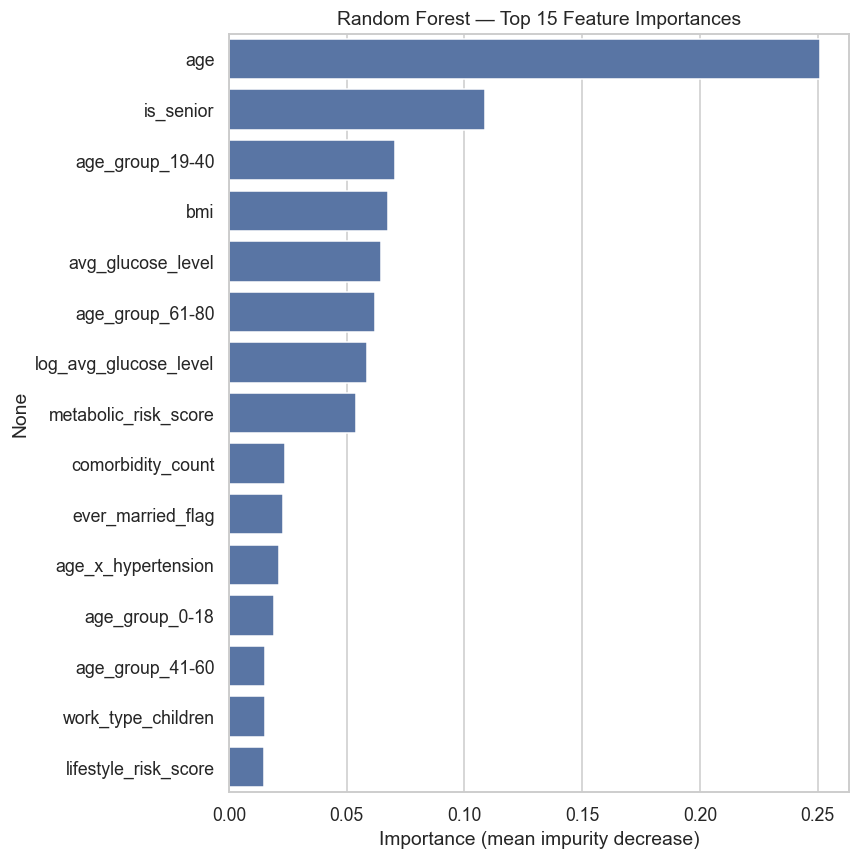

age                      0.250977
is_senior                0.108728
age_group_19-40          0.070398
bmi                      0.067510
avg_glucose_level        0.064572
age_group_61-80          0.061947
log_avg_glucose_level    0.058664
metabolic_risk_score     0.053869
comorbidity_count        0.023594
ever_married_flag        0.022959
age_x_hypertension       0.021174
age_group_0-18           0.019249
age_group_41-60          0.015250
work_type_children       0.015249
lifestyle_risk_score     0.014908
dtype: float64


In [32]:

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
top_n = 15
sns.barplot(x=importances.head(top_n).values, y=importances.head(top_n).index, color="#4C72B0")
plt.title(f"Random Forest — Top {top_n} Feature Importances")
plt.xlabel("Importance (mean impurity decrease)")
plt.tight_layout()
plt.show()

print(importances.head(top_n))



👉 **How to read this:** `age` almost always dominates in stroke-prediction models — this matches decades of epidemiological literature. Look at where your **engineered features** (Part C) rank — if `metabolic_risk_score` or `comorbidity_count` appear near the top, that confirms your domain-knowledge feature engineering added real signal beyond the raw columns! If an engineered feature ranks very low, that's a useful (and normal) research finding too — not every feature idea works, and reporting that honestly is good science.

We can sanity-check importance against simple correlation too:


In [33]:

corr_with_target = data_encoded[feature_cols + ["stroke"]].corr()["stroke"].drop("stroke").sort_values(key=abs, ascending=False)
print("Top absolute correlations with `stroke`:")
print(corr_with_target.head(10).round(3))


Top absolute correlations with `stroke`:
is_senior                  0.247
age                        0.245
age_group_61-80            0.207
comorbidity_count          0.175
age_x_hypertension         0.150
heart_disease              0.135
avg_glucose_level          0.132
glucose_category_Normal   -0.131
metabolic_risk_score       0.129
hypertension               0.128
Name: stroke, dtype: float64



## D.5 Evaluating Both Models on the Test Set

We never look at the test set until this exact moment. We'll compute the full suite of metrics you'll need for any clinical ML report: **Accuracy, Precision, Recall, F1-score, ROC-AUC**, plus **ROC curve** and **confusion matrix** plots.

> 📌 **Why not just accuracy?** With ~95% "no stroke" patients, accuracy alone is misleading (see Part B.2). **Recall** (a.k.a. sensitivity) tells us: *of all patients who really had a stroke, how many did we catch?* — usually the most clinically important number.


In [34]:

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }
    return metrics, y_pred, y_proba

dt_metrics, dt_pred, dt_proba = evaluate_model(dt_model, X_test, y_test, "Decision Tree")
rf_metrics, rf_pred, rf_proba = evaluate_model(rf_model, X_test, y_test, "Random Forest")

results_df = pd.DataFrame([dt_metrics, rf_metrics]).set_index("Model").round(3)
results_df


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Decision Tree,0.664,0.098,0.726,0.173,0.790
Random Forest,0.826,0.175,0.694,0.279,0.828


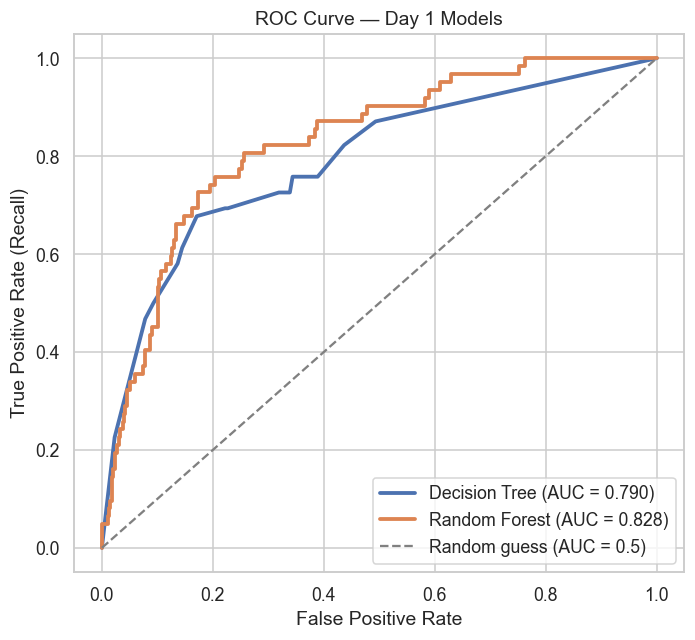

In [35]:

# --- Pretty ROC curves for both models on one plot ---
plt.figure(figsize=(6.5, 6))
for name, proba in [("Decision Tree", dt_proba), ("Random Forest", rf_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2.5, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Day 1 Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


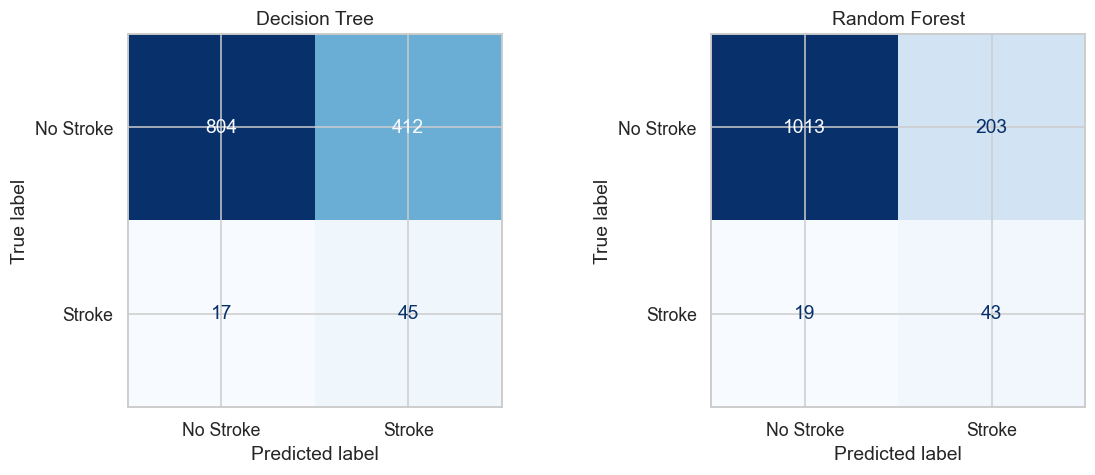

Decision Tree classification report:
               precision    recall  f1-score   support

   No Stroke       0.98      0.66      0.79      1216
      Stroke       0.10      0.73      0.17        62

    accuracy                           0.66      1278
   macro avg       0.54      0.69      0.48      1278
weighted avg       0.94      0.66      0.76      1278

Random Forest classification report:
               precision    recall  f1-score   support

   No Stroke       0.98      0.83      0.90      1216
      Stroke       0.17      0.69      0.28        62

    accuracy                           0.83      1278
   macro avg       0.58      0.76      0.59      1278
weighted avg       0.94      0.83      0.87      1278



In [36]:

# --- Confusion matrices, side by side, nicely styled ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, pred) in zip(axes, [("Decision Tree", dt_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Stroke", "Stroke"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name)
plt.tight_layout()
plt.show()

print("Decision Tree classification report:\n", classification_report(y_test, dt_pred, target_names=["No Stroke", "Stroke"]))
print("Random Forest classification report:\n", classification_report(y_test, rf_pred, target_names=["No Stroke", "Stroke"]))



👉 **Reading the confusion matrix:**

|  | Predicted: No Stroke | Predicted: Stroke |
|---|---|---|
| **Actual: No Stroke** | True Negative (TN) | False Positive (FP) |
| **Actual: Stroke** | False Negative (FN) ⚠️ | True Positive (TP) ✅ |

In a clinical screening context, a **False Negative** (telling a real stroke-risk patient "you're fine") is usually far more dangerous than a **False Positive** (extra caution for a healthy patient). This is exactly why `class_weight="balanced"` and reporting **Recall** matter so much here.

---
## Day 1 Summary & Recap 🎉

Today you went from **raw Python syntax** all the way to a **trained, evaluated machine learning pipeline** on real clinical data. Let's recap the big picture of **supervised learning**:

> **Supervised learning** = learning a mapping from **input features (X)** to a **known target label (y)**, using a labeled training set, so the model can predict `y` for *new, unseen* patients.

Today's pipeline, step by step:

1. **Data ingestion** → loaded `kku-stroke-dataset.csv` with pandas
2. **EDA** → understood distributions, missingness, imbalance, and relationships with the target
3. **Feature engineering** → imputation, clinical binning, encoding, composite risk scores, skew correction
4. **Stratified split** → kept class balance identical across train/test
5. **Model training** → Decision Tree (interpretable, single tree) and Random Forest (ensemble, usually stronger)
6. **Feature importance** → validated which engineered features actually carried signal
7. **Evaluation** → Accuracy, Precision, Recall, F1, ROC-AUC, ROC curve, confusion matrix

### 🔮 Tomorrow (Day 2) we will:
- Learn **Logistic Regression** — the mathematical ancestor of every neural network
- Understand the **sigmoid neuron** — the building block of Deep Learning
- Build our first **PyTorch neural networks**
- Compare **classical ML vs. Deep Learning** on the exact same stroke dataset
- Close with **best practices, reproducibility, and AI ethics for public health research**

See you tomorrow! 👋
